Dataset creation for Sentinel-2 cross-season image matching.
Finds cloud-free TCI scenes from the same geographic tile across different seasons,
cuts aligned 512×512 patch pairs, and saves them for keypoint matching training.

## 0. Setup

In [17]:
!pip install -q rasterio opencv-python-headless

In [18]:
import json
import os
import glob
import random

import numpy as np
import rasterio
import cv2
from PIL import Image
import matplotlib.pyplot as plt

random.seed(42)
np.random.seed(42)

DATASET_DIR = "/kaggle/input/datasets/isaienkov/deforestation-in-ukraine"
os.path.exists(DATASET_DIR)


True

## 1. Find TCI files

In [19]:
if not os.path.exists(DATASET_DIR):
    print("DATASET_DIR does not exist — check the exact path under /kaggle/input/")
else:
    print("Top-level contents of DATASET_DIR:")
    print(os.listdir(DATASET_DIR))


Top-level contents of DATASET_DIR:
['S2A_MSIL1C_20160212T084052_N0201_R064_T36UYA_20160212T084510', 'S2A_MSIL1C_20160621T084012_N0204_R064_T36UYA_20160621T084513', 'S2A_MSIL1C_20190606T083601_N0207_R064_T36UXA_20190606T104250', 'S2B_MSIL1C_20190313T083739_N0207_R064_T36UYA_20190313T122406', 'S2B_MSIL1C_20190611T083609_N0207_R064_T36UYA_20190611T122426', 'S2A_MSIL1C_20190427T083601_N0207_R064_T36UXA_20190427T100851', 'S2B_MSIL1C_20190701T083609_N0207_R064_T36UYA_20190701T113927', 'S2B_MSIL1C_20180726T084009_N0206_R064_T36UXA_20180726T104227', 'S2B_MSIL1C_20190721T083609_N0208_R064_T36UYA_20190721T110447', 'S2B_MSIL1C_20190621T083609_N0207_R064_T36UYA_20190621T104242', 'S2A_MSIL1C_20190825T083601_N0208_R064_T36UYA_20190825T104312', 'S2A_MSIL1C_20190318T083701_N0207_R064_T36UYA_20190318T122410', 'S2A_MSIL1C_20190706T083611_N0207_R064_T36UYA_20190706T104407', 'S2A_MSIL1C_20160509T082612_N0202_R021_T36UYA_20160509T083548', 'S2A_MSIL1C_20190815T083601_N0208_R064_T36UYA_20190815T123742', 'S2B

In [20]:
all_tci_files = glob.glob(os.path.join(DATASET_DIR, "**", "*TCI*.jp2"), recursive=True)
len(all_tci_files)


50

In [21]:
import re

date_pattern = re.compile(r"(20\d{6})T\d{6}")
tile_pattern = re.compile(r"(T\d{2}[A-Z]{3})")

tci_by_tile_date: dict[str, dict[str, str]] = {}
for f in all_tci_files:
    basename = os.path.basename(f)
    d_match  = date_pattern.search(basename)
    t_match  = tile_pattern.search(f)  # search full path — tile is in the folder name
    if d_match and t_match:
        date = d_match.group(1)
        tile = t_match.group(1)
        tci_by_tile_date.setdefault(tile, {})[date] = f

for tile, dates in sorted(tci_by_tile_date.items()):
    print(f"Tile {tile}: {len(dates)} dates")

chosen_tile = max(tci_by_tile_date, key=lambda t: len(tci_by_tile_date[t]))
tci_by_date = tci_by_tile_date[chosen_tile]
print(f"\nUsing tile: {chosen_tile}  ({len(tci_by_date)} candidate dates)")
sorted(tci_by_date.keys())


Tile T36UXA: 12 dates
Tile T36UYA: 38 dates

Using tile: T36UYA  (38 candidate dates)


['20160212',
 '20160330',
 '20160405',
 '20160502',
 '20160509',
 '20160618',
 '20160621',
 '20160830',
 '20161026',
 '20161121',
 '20161205',
 '20190313',
 '20190318',
 '20190328',
 '20190402',
 '20190407',
 '20190412',
 '20190417',
 '20190422',
 '20190427',
 '20190517',
 '20190601',
 '20190606',
 '20190611',
 '20190616',
 '20190621',
 '20190626',
 '20190701',
 '20190706',
 '20190721',
 '20190726',
 '20190805',
 '20190810',
 '20190815',
 '20190825',
 '20190830',
 '20190904',
 '20190909']

## 2. Filter by cloud cover

Scan each TCI at low resolution — keep only dates with < 20 % bright pixels.

In [22]:
CLOUD_THRESH   = 0.20
SAMPLE_SIZE    = 512
MIN_MONTH_GAP  = 3
TILES_PER_PAIR = 5
TILE_SIZE      = 512

def cloud_fraction(path, sample=SAMPLE_SIZE):
    with rasterio.open(path) as src:
        arr = src.read(1, out_shape=(sample, sample),
                       resampling=rasterio.enums.Resampling.nearest)
    return float((arr > 230).mean())

print(f"{'Date':<12} {'Cloud':>6}  Status")
print("-" * 30)

clear_dates = {}
for date in sorted(tci_by_date.keys()):
    cf    = cloud_fraction(tci_by_date[date])
    month = int(date[4:6])
    ok    = cf < CLOUD_THRESH
    print(f"{date}   {cf:5.0%}  {'✓' if ok else '✗'}")
    if ok:
        clear_dates[date] = (tci_by_date[date], month)

dates_list = sorted(clear_dates.keys())
print(f"\nCloud-free: {len(dates_list)} / {len(tci_by_date)} dates")
print(dates_list)

if len(dates_list) < 2:
    raise RuntimeError(
        f"Only {len(dates_list)} cloud-free date(s) found. "
        "Try raising CLOUD_THRESH (e.g. 0.30) or check the tile."
    )

Date          Cloud  Status
------------------------------
20160212     84%  ✗
20160330      1%  ✓
20160405      0%  ✓
20160502     18%  ✓
20160509      0%  ✓
20160618      0%  ✓
20160621      0%  ✓
20160830      0%  ✓
20161026      0%  ✓
20161121      3%  ✓
20161205     39%  ✗
20190313      6%  ✓
20190318     22%  ✗
20190328     21%  ✗
20190402      5%  ✓
20190407      5%  ✓
20190412     14%  ✓
20190417      4%  ✓
20190422     16%  ✓
20190427      0%  ✓
20190517     10%  ✓
20190601     11%  ✓
20190606      0%  ✓
20190611      0%  ✓
20190616     14%  ✓
20190621     12%  ✓
20190626      0%  ✓
20190701      6%  ✓
20190706     42%  ✗
20190721     29%  ✗
20190726     51%  ✗
20190805     35%  ✗
20190810     20%  ✗
20190815      0%  ✓
20190825      0%  ✓
20190830      0%  ✓
20190904      0%  ✓
20190909      1%  ✓

Cloud-free: 29 / 38 dates
['20160330', '20160405', '20160502', '20160509', '20160618', '20160621', '20160830', '20161026', '20161121', '20190313', '20190402', '20190407', '20190412

## 3. Cut cross-season tile pairs

For every pair of cloud-free dates ≥ 3 months apart, cut `TILES_PER_PAIR` random
512×512 crops from the **same pixel coordinates** in both images, apply CLAHE, save as PNG.

In [23]:
from itertools import combinations

def enhance(tile):
    tile = tile.clip(0, 255).astype(np.uint8)
    lab = cv2.cvtColor(tile, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2RGB)

OUTPUT_DIR = "dataset/pairs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Loading cloud-free images into memory...")
images = {}
for date in dates_list:
    path, month = clear_dates[date]
    print(f"  {date} ... ", end="", flush=True)
    with rasterio.open(path) as src:
        arr = src.read()
    images[date] = np.transpose(arr, (1, 2, 0))
    print(f"{images[date].shape}")

metadata = []
pair_id  = 0

for date_a, date_b in combinations(dates_list, 2):
    month_a = clear_dates[date_a][1]
    month_b = clear_dates[date_b][1]
    gap = abs(month_a - month_b)
    gap = min(gap, 12 - gap)
    if gap < MIN_MONTH_GAP:
        continue

    img_a = images[date_a]
    img_b = images[date_b]
    h = min(img_a.shape[0], img_b.shape[0])
    w = min(img_a.shape[1], img_b.shape[1])

    if h < TILE_SIZE or w < TILE_SIZE:
        print(f"{date_a} ↔ {date_b}  skipped — image too small ({h}×{w})")
        continue

    saved = 0
    attempts = 0
    while saved < TILES_PER_PAIR and attempts < TILES_PER_PAIR * 20:
        attempts += 1
        row = random.randint(0, h - TILE_SIZE)
        col = random.randint(0, w - TILE_SIZE)
        ta  = img_a[row:row+TILE_SIZE, col:col+TILE_SIZE]
        tb  = img_b[row:row+TILE_SIZE, col:col+TILE_SIZE]

        if ta.mean() > 240 or tb.mean() > 240:  # cloud remnant
            continue
        if ta.mean() < 5  or tb.mean() < 5:      # no data
            continue

        ta = enhance(ta);  tb = enhance(tb)
        name_a = f"pair_{pair_id:03d}_a.png"
        name_b = f"pair_{pair_id:03d}_b.png"
        Image.fromarray(ta).save(os.path.join(OUTPUT_DIR, name_a))
        Image.fromarray(tb).save(os.path.join(OUTPUT_DIR, name_b))
        metadata.append({
            "pair_id":   pair_id,
            "image_a":   name_a, "image_b":  name_b,
            "date_a":    date_a, "date_b":   date_b,
            "month_gap": gap,
            "row": row,  "col": col, "tile_size": TILE_SIZE,
        })
        pair_id += 1
        saved   += 1

    print(f"{date_a} ↔ {date_b}  gap={gap}mo  → {saved} tiles")

with open("dataset/pairs_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\nTotal pairs saved: {pair_id}")

Loading cloud-free images into memory...
  20160330 ... (10980, 10980, 3)
  20160405 ... (10980, 10980, 3)
  20160502 ... (10980, 10980, 3)
  20160509 ... (10980, 10980, 3)
  20160618 ... (10980, 10980, 3)
  20160621 ... (10980, 10980, 3)
  20160830 ... (10980, 10980, 3)
  20161026 ... (10980, 10980, 3)
  20161121 ... (10980, 10980, 3)
  20190313 ... (10980, 10980, 3)
  20190402 ... (10980, 10980, 3)
  20190407 ... (10980, 10980, 3)
  20190412 ... (10980, 10980, 3)
  20190417 ... (10980, 10980, 3)
  20190422 ... (10980, 10980, 3)
  20190427 ... (10980, 10980, 3)
  20190517 ... (10980, 10980, 3)
  20190601 ... (10980, 10980, 3)
  20190606 ... (10980, 10980, 3)
  20190611 ... (10980, 10980, 3)
  20190616 ... (10980, 10980, 3)
  20190621 ... (10980, 10980, 3)
  20190626 ... (10980, 10980, 3)
  20190701 ... (10980, 10980, 3)
  20190815 ... (10980, 10980, 3)
  20190825 ... (10980, 10980, 3)
  20190830 ... (10980, 10980, 3)
  20190904 ... (10980, 10980, 3)
  20190909 ... (10980, 10980, 3)
20

## 4. Preview — first 3 pairs

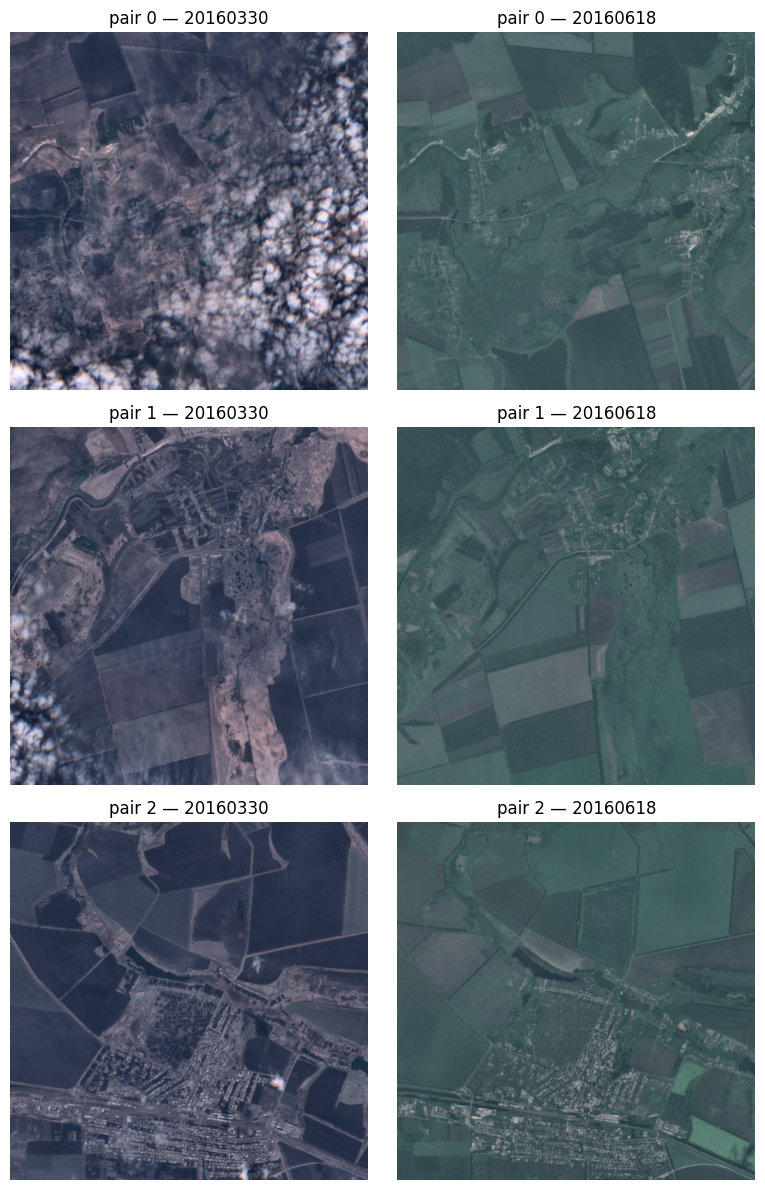

In [24]:
n_preview = min(3, len(metadata))
fig, axes = plt.subplots(n_preview, 2, figsize=(8, 4 * n_preview))
if n_preview == 1:
    axes = axes[np.newaxis, :]

for i in range(n_preview):
    m = metadata[i]
    img_a = np.array(Image.open(os.path.join(OUTPUT_DIR, m["image_a"])))
    img_b = np.array(Image.open(os.path.join(OUTPUT_DIR, m["image_b"])))
    axes[i, 0].imshow(img_a)
    axes[i, 0].set_title(f"pair {i} — {m['date_a']}")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(img_b)
    axes[i, 1].set_title(f"pair {i} — {m['date_b']}")
    axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

## 5. Zip for download

In [25]:
import shutil

shutil.make_archive("/kaggle/working/dataset_pairs", "zip", "/kaggle/working/dataset")

'/kaggle/working/dataset_pairs.zip'